### Progress report 09/17/26:
- I followed this guide: https://learn.adafruit.com/how-to-fuse-motion-sensor-data-into-ahrs-orientation-euler-quaternions/sensor-fusion-algorithms
- I have tested the output using: https://adafruit.github.io/Adafruit_WebSerial_3DModelViewer/


### TODO 
- The axis are not aligned accurately, and the heading is inverted (temporarily fixed).

- The heading drifts too much. 
    
    - Need to tune magnetometer, improve calibration, operate in better location, or other?? 
    
    - https://github.com/PaulStoffregen/NXPMotionSense/blob/master/examples/Orientation/Orientation.ino
    - https://www.nxp.com/docs/en/application-note/AN4248.pdf
    - https://forum.arduino.cc/t/ahrs-library-calibration-tutorial/1028116
    - https://www.st.com/en/mems-and-sensors/lis3mdl.html


-DONE I need to print an enclosure so I can more accurately calibrate

    - https://learn.adafruit.com/3d-printed-case-for-adafruit-feather/parts
    - battery enclosure is too narrow. needs > 51mm
    - main enclosure is too short. needs +3mm
    - rethink enclosure entirely?

- DONE I need to figure out battery

    - battery pack is working with on-board charging
    - 

- solar?

    - https://www.adafruit.com/category/67

- DONE I need to figure out how to send the data via bluetooth 
    
    - using BLE UART aka BLUART

- I need to recieve the BLUART data on the Rpi5 in a python script

    

- Does serial connect to other computers?
    
    - yes


Rpi 5 Kraken SDR reciever:

1. Power on
2. 


|                                   |            |           |
|-----------------------------------|------------|-----------|
| reading within 0-5 seconds        |            |           |
| analog (deg) (+-3deg uncertainty) | DEV1(blue) | DEV2(red) |
| 200                               | 199        | 202       |
| 0                                 | 359        | 1.8       |
| 40                                | 64         | 50        |
| 90                                | 117        | 99        |
| 140                               | 158        | 145       |
| 80                                | 107        | 88        |
| 0                                 | 358        | 5         |
| 180                               | 184        | 180       |
| 190                               | 191        | 189       |
| 120                               | 145        | 128       |
| 190                               | 195        | 194       |
| 250                               | 235        | 246       |
|                                   |            |           |

|                                   |                |           |
|-----------------------------------|----------------|-----------|
| reading after +30s                | original board | new board |
| analog (deg) (+-3deg uncertainty) | DEV1(blue)     | DEV2(red) |
| 250                               | 235            | 248       |
| 0                                 | 355            | 3.5       |
| 90                                | 113            | 95        |
| 180                               | 184            | 181       |
| 270                               | 250            | 266       |

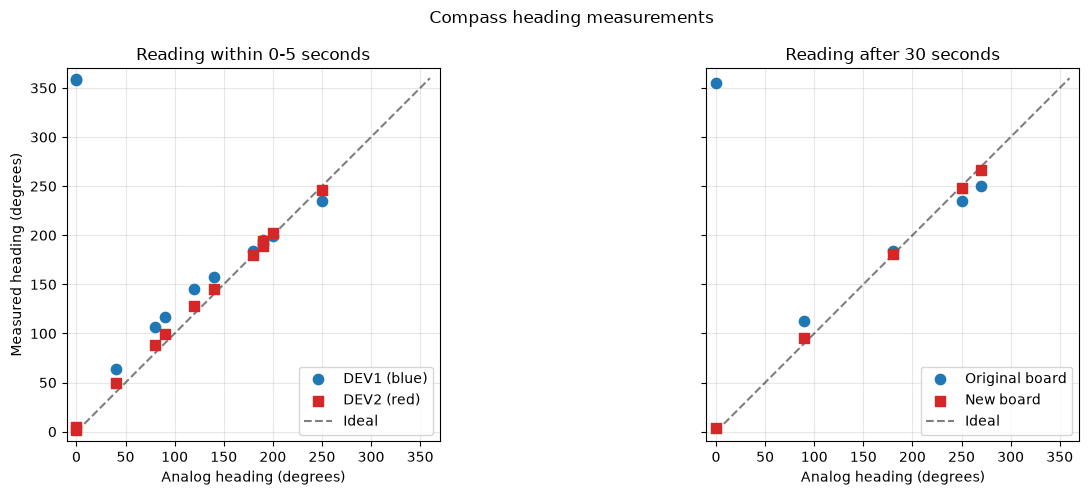

Within 0-5 seconds:
(200, 199, 202)
(0, 359, 1.8)
(40, 64, 50)
(90, 117, 99)
(140, 158, 145)
(80, 107, 88)
(0, 358, 5)
(180, 184, 180)
(190, 191, 189)
(120, 145, 128)
(190, 195, 194)
(250, 235, 246)
After 30 seconds:
(250, 235, 248)
(0, 355, 3.5)
(90, 113, 95)
(180, 184, 181)
(270, 250, 266)


In [2]:
import matplotlib.pyplot as plt

plt.close("all")

# Measurements copied from the tables above.
within_5s = {
    "analog_deg": [200, 0, 40, 90, 140, 80, 0, 180, 190, 120, 190, 250],
    "DEV1 (blue)": [199, 359, 64, 117, 158, 107, 358, 184, 191, 145, 195, 235],
    "DEV2 (red)": [202, 1.8, 50, 99, 145, 88, 5, 180, 189, 128, 194, 246],
}

after_30s = {
    "analog_deg": [250, 0, 90, 180, 270],
    "Original board": [235, 355, 113, 184, 250],
    "New board": [248, 3.5, 95, 181, 266],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for axis, data, title in zip(
    axes,
    [within_5s, after_30s],
    ["Reading within 0-5 seconds", "Reading after 30 seconds"],
):
    series_names = list(data)[1:]
    styles = [("o", "tab:blue"), ("s", "tab:red")]
    for series_name, (marker, color) in zip(series_names, styles):
        axis.scatter(
            data["analog_deg"],
            data[series_name],
            marker=marker,
            color=color,
            s=55,
            label=series_name,
            zorder=3,
        )
    axis.plot([0, 360], [0, 360], "k--", alpha=0.5, label="Ideal")
    axis.set_title(title)
    axis.set_xlabel("Analog heading (degrees)")
    axis.set_xlim(-10, 370)
    axis.set_ylim(-10, 370)
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.3)
    axis.legend()

axes[0].set_ylabel("Measured heading (degrees)")
fig.suptitle("Compass heading measurements")
fig.tight_layout()
plt.show()

print("Within 0-5 seconds:")
for row in zip(*within_5s.values()):
    print(row)
print("After 30 seconds:")
for row in zip(*after_30s.values()):
    print(row)